#Caso aprobación de tarjetas de credito


## 1. Importar Librerías

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split                    # Divide los datos en entrenamiento y prueba.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer                                # Rellena valores faltantes, con la mediana o la moda.
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression                     # Regresión Logística, clasificación binaria.
from sklearn.tree import DecisionTreeClassifier                         # Árbol de Decisión
from sklearn.neural_network import MLPClassifier                        # Red neuronal multicapa para clasificación.
from sklearn.neighbors import KNeighborsClassifier                      # Clasifica según los vecinos más cercanos.                  
from sklearn.svm import SVC                                             # Máquina de vectores de soporte para clasificación.

from sklearn.model_selection import cross_val_score                     # Validación cruzada.
from sklearn.model_selection import RepeatedStratifiedKFold             # Hace particiones repetidas conservando la proporción de clases.
from sklearn.model_selection import GridSearchCV                        # Busca automáticamente la mejor combinación de hiperparámetros.
from sklearn.metrics import confusion_matrix

## 2. Importar Dataset

In [21]:
mypath = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
data = pd.read_csv(mypath, sep=" ", header=None)
data.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','class']
print(data.shape)
data.head()

(690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


Hallazgos: Cuenta con 690 datos y 15 variables

In [22]:
data['A4'].value_counts()

A4
2    525
1    163
3      2
Name: count, dtype: int64

Hallazgos: 
La columna A4 tiene 690 registros en total.
Se observa es que la categoría 2 domina, mientras que la categoría 3 aparece únicamente 2 registros.

### 2.1 Reconfiguración

In [23]:
data['A4'] = data['A4'].map({2:2, 1:0, 3:0})
data['A5'] = data['A5'].map({1:1,2:0,3:3,4:4,5:0,6:6,7:7,8:8,9:9,10:0,11:11,12:0,13:13,14:14})
data['A6'] = data['A6'].map({1:1,2:0,3:0,4:4,5:5,7:0,8:8,9:0})

### 2.2 Definir variables

In [24]:

X = data.iloc[:,:-1]  
Y = data.iloc[:,-1]     #

## 3. ENTRENAMIENTO, VALIDACIÓN Y PRUEBA

## 3.1 PRE ENTRENAMIENTO

### 3.1.1 Train-Test Split
 * 20%: Test
 * 80%: Validación


In [25]:
Xtv, Xtest, ytv, ytest = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1)  # stratify=Y => = tamaño de muestra por partición.

print(Xtv.shape, ': dimensión de datos de entrada para entrenamiento y validación')
print(Xtest.shape, ': dimensión de datos de entrada para prueba')  

print(ytv.shape, ': dimensión de variable de salida para entrenamiento y validación')
print(ytest.shape, ': dimensión de variable de salida para prueba')

(552, 14) : dimensión de datos de entrada para entrenamiento y validación
(138, 14) : dimensión de datos de entrada para prueba
(552,) : dimensión de variable de salida para entrenamiento y validación
(138,) : dimensión de variable de salida para prueba


### 3.1.2 ¿Las clases se encuentran balanceadas?

In [26]:
ytv.sum() / ytv.shape[0] 

np.float64(0.44565217391304346)

Hallazgos: 4.6 % y 55.4 % indican que las clases están bastante equilibradas.

## 3.1.2 Preprocesamiento

In [27]:
# Transformaciones a factores numéricos de entrada:
num_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='median')),
                                 ('escalaNum', MinMaxScaler(feature_range=(1,2)))])   
num_pipeline_nombres = ['A2','A3','A7','A10','A13','A14']

# Transformaciones a factores categóricos de entrada:
catImp_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent'))])  
catImp_pipeline_nombres = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
catOHE_pipeline = Pipeline(steps = [('OneHotE', OneHotEncoder(drop='first'))])
catOHE_pipeline_nombres = [ 'A4','A5','A6','A12']

# Conjuntamos las transformaciones numéricas y categóricas que se estarán aplicando a los datos de entrada:
columnasTransformer = ColumnTransformer(transformers = [('numpipe', num_pipeline, num_pipeline_nombres),
                                                        ('catimp', catImp_pipeline, catImp_pipeline_nombres),
                                                        ('catohe', catOHE_pipeline, catOHE_pipeline_nombres)],
                                        remainder='passthrough')

## 3.2 ENTRENAMIENTO

### 3.2.1 Seteos de Modelos

In [28]:
def get_models():

  modelos = list()
  nombres = list()

  # LR - Regresión Logística:
  modelos.append(LogisticRegression(solver='liblinear'))
  nombres.append('LR')

  # DT - Árbol de Decisión:
  modelos.append(DecisionTreeClassifier())
  nombres.append('DT')

  # MLP - Red Neuronal Artificial / Perceptrón Lineal Multicapa:  
  modelos.append(MLPClassifier(hidden_layer_sizes=(30,), max_iter=3000))
  nombres.append('MLP')

  # SVM - Máquina de Vector Soporte:
  modelos.append(SVC(gamma='scale'))
  nombres.append('SVM')

  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier())
  nombres.append('kNN')

  return modelos, nombres

## 3.2.2 Pipeline

In [29]:
modelos, nombres = get_models()  # Cross Validation | Evitar filtraciones
resultados = list()   

for i in range(len(modelos)):
  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)                  # Cross Validation
  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)       # scoring='accuracy'
  resultados.append(scores)

  print('>> %s: %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))

>> LR: 0.861 (0.039)
>> DT: 0.815 (0.051)
>> MLP: 0.839 (0.044)
>> SVM: 0.850 (0.041)
>> kNN: 0.791 (0.040)


### 3.2.3 Gráfico de Bigotes

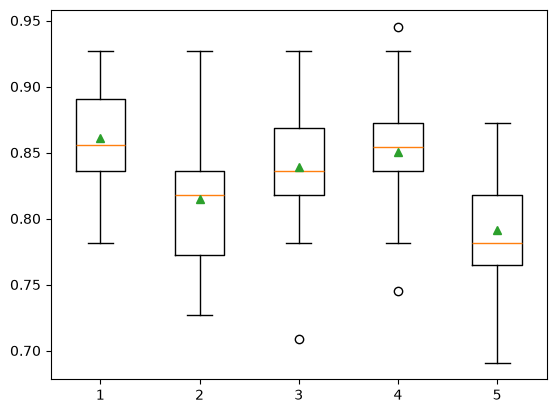

In [30]:
plt.boxplot(resultados, label=nombres, showmeans=True)
plt.show()

Hallazgos:
De acuerdo al accuracy, la RL es el mejor modelo con un valor de 0.861 y con una DES relativamente pequeña (0.039).

### 3.2.3 Regresión Logistica con Regularizaciones

### 3.2.3.1 Seteo de Modelos

In [31]:
def get_modelsRegs():

  modelos, nombres = list(), list()
  # LR - sin regularización:
  modelos.append(LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000, random_state=1))
  nombres.append('LR')

  # Lasso:
  modelos.append(LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, C=1., random_state=1))
  nombres.append('LASSO')

  # Ridge:
  modelos.append(LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, C=10.01, random_state=1))
  nombres.append('RIDGE')

  # Elastic-Net:
  modelos.append(LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=4000, C=1., random_state=1))
  nombres.append('EN')

  return modelos, nombres

ENTRENAMIENTO Y VALIDACIÓN

c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

>> LR 0.868 (0.051)


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

>> LASSO 0.867 (0.046)


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

>> RIDGE 0.869 (0.048)


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

>> EN 0.863 (0.048)


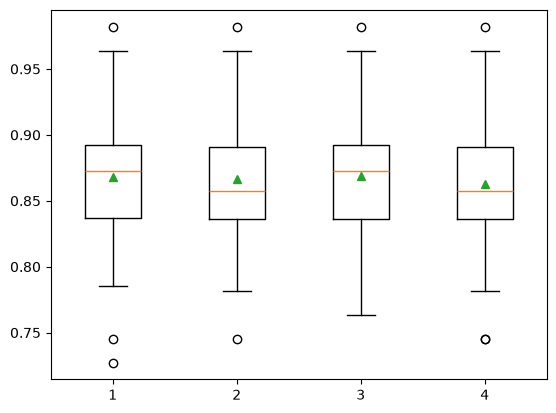

In [32]:
modelos, nombres = get_modelsRegs()
resultados = list() 

for i in range(len(modelos)):
  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)
  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)
  resultados.append(scores)
  print('>> %s %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))
plt.boxplot(resultados, label=nombres, showmeans=True)

plt.show()

Hallazgos: 
Modelos de Regresión Logística con y sin regularización presentan desempeños muy similares.
Sin embargo, Ridge muestra ligeramente mejor precisión central y una variabilidad comparable al resto, por lo que puede considerarse la opción más conveniente.

## Fine Tuning (Ajuste Fino)

Crea un modelo de LogisticRegression, prueba varios valores de C y solver.
Evalúa combinaciones con validación cruzada y compara los resultados usando accuracy.

In [33]:
# RIDGE - métrica L2:

modelo = LogisticRegression(penalty='l2', max_iter=10000, random_state=1)
dicc_grid = {'C':[0.0001,0.01,0.1,1.0,10.,100.],
             'solver':['newton-cg','lbfgs','liblinear','sag','saga']
             }
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)
grid = GridSearchCV(estimator=modelo, 
                    param_grid=dicc_grid, 
                    cv=cv, 
                    scoring='accuracy')

Nos dice cual parámetro usar:

In [34]:
# Transformamos los datos de entrada:

Xx = columnasTransformer.fit_transform(Xtv)
 
# Llevamos a cabo el proceso de etrenamiento con validación-cruzada y búsqueda de malla.
# Observa que de acuerdo a las opciones incluidas en la malla, se estarán realizando (6)(5)=30 
# combinaciones diferentes, además de las (10)(5)=50 particiones de la validación-cruzada,
# lo cual implica también un mayor tiempo de entrenamiento.

grid.fit(Xx, np.ravel(ytv))

print('Mejor valor de exactitud obtenido con la mejor combinación:', grid.best_score_)
print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)
print('Métrica utilizada:', grid.scoring)

c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

Mejor valor de exactitud obtenido con la mejor combinación: 0.8695389610389609
Mejor combinación de valores encontrados de los hiperparámetros: {'C': 100.0, 'solver': 'liblinear'}
Métrica utilizada: accuracy


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Resultados:
Mejor valor de exactitud obtenido con la mejor combinación: 0.8695389610389609
Mejor combinación de valores encontrados de los hiperparámetros: {'C': 100.0, 'solver': 'liblinear'}
Métrica utilizada: accuracy

In [35]:
modelo = LogisticRegression(
    penalty='l2',
    max_iter=10000,
    C=100.0,
    solver='liblinear',
    random_state=1
)

# Entrenamos el modelo por última vez con los datos de entrenamiento y validación conjuntos:
Xct = columnasTransformer.fit(Xtv)
Xxt = Xct.transform(Xtv)
modelo.fit(Xxt, np.ravel(ytv))

# Transformamos los datos de prueba y los utilizamos por primera vez para obtener sus predicciones
# y desempeño del modelo:
Xxtest = Xct.transform(Xtest)
print(modelo.score(Xxtest, np.ravel(ytest)))  # Entrenar modelo final con dataset de prueba

0.8405797101449275


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



y_pred = modelo.predict(Xxtest)
cm = confusion_matrix(ytest, y_pred)
txt = ['Verdaderos Negativos', 'Falsos Positivos',
       'Falsos Negativos', 'Verdaderos Positivos']

frecuencia = [f"{value:.0f}" for value in cm.flatten()]
porcentaje = [f"{value / np.sum(cm):.1%}" for value in cm.flatten()]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(txt, frecuencia, porcentaje)]
labels = np.array(labels).reshape(2, 2)

ax = sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)
ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
plt.show()

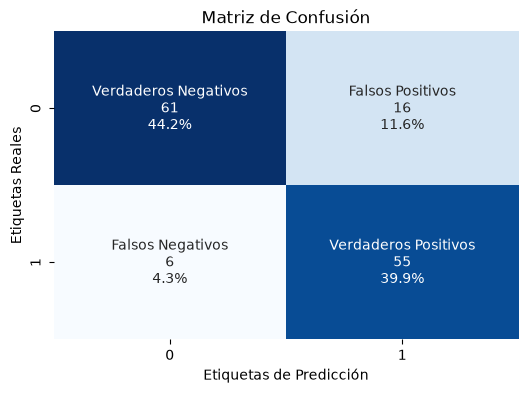

In [36]:
from sklearn.metrics import confusion_matrix

y_pred = modelo.predict(Xxtest)
cm = confusion_matrix(np.ravel(ytest), y_pred, labels=[0, 1])
txt = ['Verdaderos Negativos', 'Falsos Positivos',
       'Falsos Negativos', 'Verdaderos Positivos']

frecuencia = [f"{value:.0f}" for value in cm.flatten()]
porcentaje = [f"{value / np.sum(cm):.1%}" for value in cm.flatten()]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(txt, frecuencia, porcentaje)]
labels = np.array(labels).reshape(2, 2)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)
ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
plt.title("Matriz de Confusión")
plt.show()

Hallazgos: 
El modelo presenta un rendimiento adecuado y una buena capacidad de detección de la clase positiva. Su principal fortaleza es el bajo número de falsos negativos, aunque todavía existe margen de mejora en la reducción de falsos positivos.